In [1]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd


In [2]:
file_path = '/content/drive/MyDrive/FYP/Datasets/machine_learning_balance_UNSW_NB15_data.csv'
df = pd.read_csv(file_path)
print(df)

             dur  spkts  dpkts         sload         dload  smeansz  dmeansz  \
0       0.000009      2      0  5.066666e+07  0.000000e+00       57        0   
1       0.000008      2      0  5.700000e+07  0.000000e+00       57        0   
2       0.025125      8     10  2.887960e+05  2.362587e+05      130       82   
3       0.051998     48     50  4.481711e+05  4.601100e+06       62      610   
4       0.000009      2      0  5.066666e+07  0.000000e+00       57        0   
...          ...    ...    ...           ...           ...      ...      ...   
642561  0.004613      4      4  7.387817e+05  4.058097e+05      142       78   
642562  0.015910     46     48  1.403897e+06  1.543734e+07       62      653   
642563  0.000008      2      0  5.700000e+07  0.000000e+00       57        0   
642564  0.000008      2      0  1.320000e+08  0.000000e+00      132        0   
642565  1.401753    102    100  8.259944e+04  9.681021e+04      143      171   

          sintpkt    dintpkt    synack 

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
X = df.drop('label', axis=1)
y = df['label']

# Replace infinite and missing values
X = X.replace([float('inf'), -float('inf')], pd.NA)
X = X.fillna(0)


In [5]:
sampled_indices = X.sample(n=10000, random_state=42).index
X = X.loc[sampled_indices]
y = y.loc[sampled_indices]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [8]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')  # You can try 'linear', 'poly', etc.
svm_model.fit(X_train_scaled, y_train)


SVC()

In [9]:
y_pred = svm_model.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9545

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.93      0.95      1035
           1       0.93      0.98      0.95       965

    accuracy                           0.95      2000
   macro avg       0.96      0.96      0.95      2000
weighted avg       0.96      0.95      0.95      2000


Confusion Matrix:
 [[960  75]
 [ 16 949]]


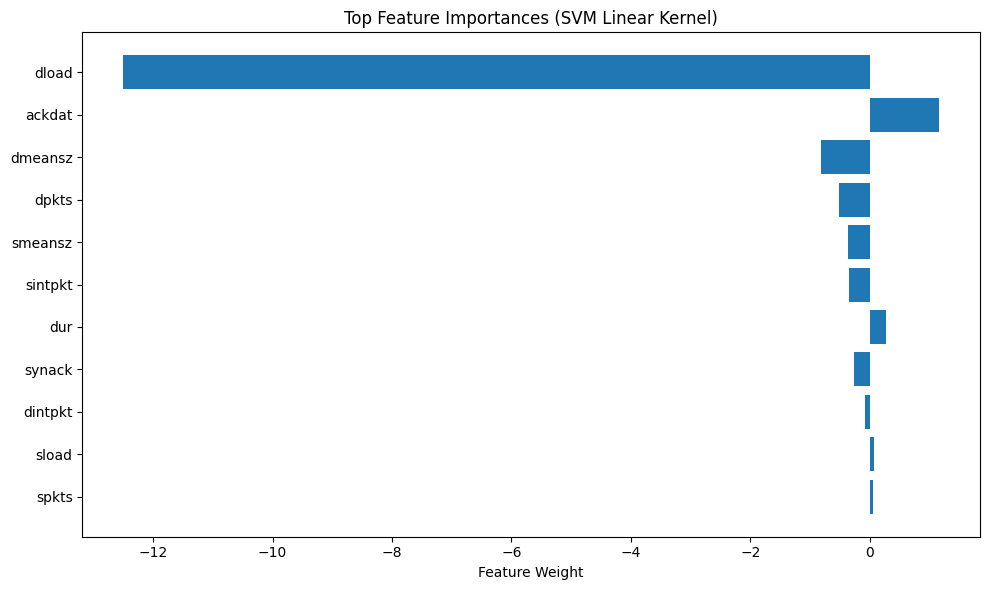

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Use only if you're training with a linear kernel
svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(X_train_scaled, y_train)

# Get feature weights for binary classification
coefs = svm_model.coef_.ravel()
feature_names = X.columns

# Sort feature indices by absolute importance
indices = np.argsort(np.abs(coefs))[::-1]
top_n = min(20, len(coefs))  # Adjust top_n if fewer features

# Plot
plt.figure(figsize=(10, 6))
plt.barh(range(top_n), coefs[indices[:top_n]][::-1], align='center')
plt.yticks(range(top_n), feature_names[indices[:top_n]][::-1])
plt.xlabel("Feature Weight")
plt.title("Top Feature Importances (SVM Linear Kernel)")
plt.tight_layout()
plt.show()
